In [1]:
!python --version

Python 3.13.15


In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.0Gi       8.8Gi       2.2Mi       3.2Gi        11Gi
Swap:             0B          0B          0B


In [15]:
!pip install -q scanpy anndata pandas numpy matplotlib seaborn scikit-learn

In [6]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Scanpy:", sc.__version__)
print("AnnData:", anndata.__version__)

Scanpy: 1.12.4
AnnData: 0.13.4


In [22]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [23]:
adata.n_obs

2700

In [24]:
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

Cells: 2700
Genes: 32738


In [25]:
adata.X.shape

(2700, 32738)

In [26]:
adata.var_names[:20]

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10', 'OR4F29', 'RP4-669L17.2', 'RP5-857K21.15',
       'RP5-857K21.1', 'RP5-857K21.2', 'RP5-857K21.3', 'RP5-857K21.4',
       'RP5-857K21.5', 'OR4F16', 'RP11-206L10.3'],
      dtype='str', name='index')

In [27]:
adata.obs.columns
adata.obs.head()

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


# basic ***qc***

In [28]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")

In [29]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

In [30]:
adata.obs[
    ["n_genes_by_counts",
     "total_counts",
     "pct_counts_mt"]
].head()

,n_genes_by_counts,total_counts,pct_counts_mt
index,,,
AAACATACAACCAC-1,781,2421.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,1.743085
AAACCGTGTATGCG-1,522,981.0,1.223242


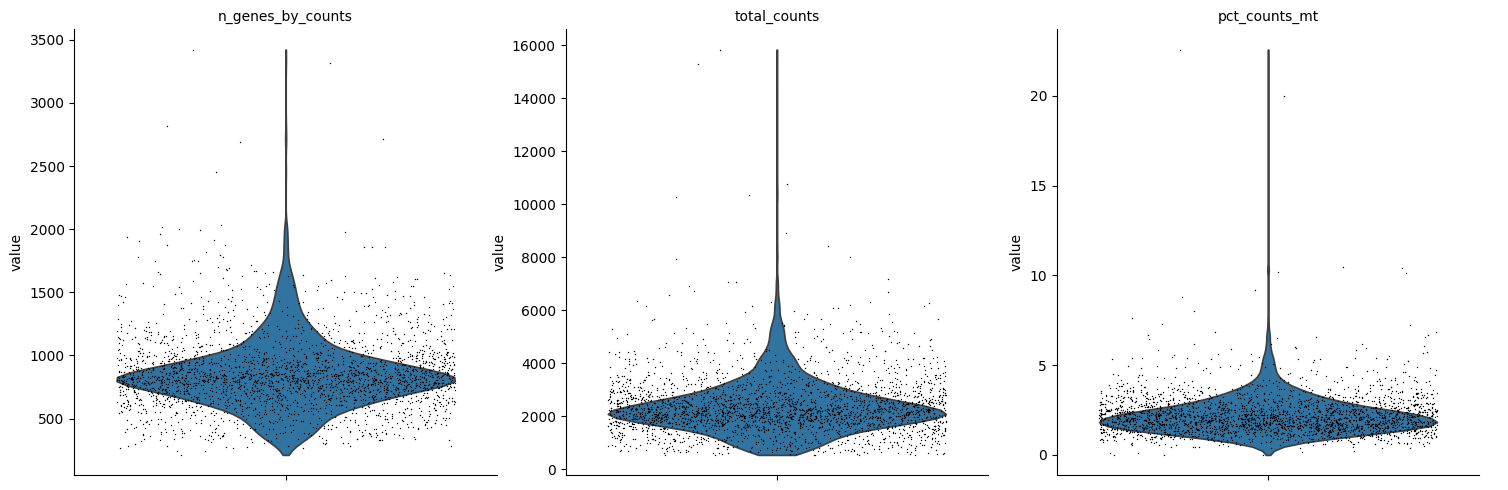

In [31]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts",
     "total_counts",
     "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [32]:
adata = adata[
    adata.obs.n_genes_by_counts > 200,
    :
].copy()

In [33]:
adata = adata[
    adata.obs.pct_counts_mt < 10,
    :
].copy()

In [34]:
print(adata)

AnnData object with n_obs × n_vars = 2694 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None (.X)


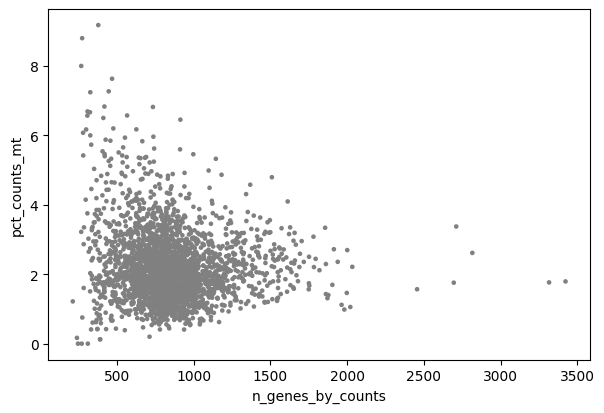

In [35]:
sc.pl.scatter(
    adata,
    x="n_genes_by_counts",
    y="pct_counts_mt"
)

In [36]:
sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

In [37]:
sc.pp.log1p(adata)

In [38]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

In [39]:
adata.var["highly_variable"].sum()

np.int64(2000)

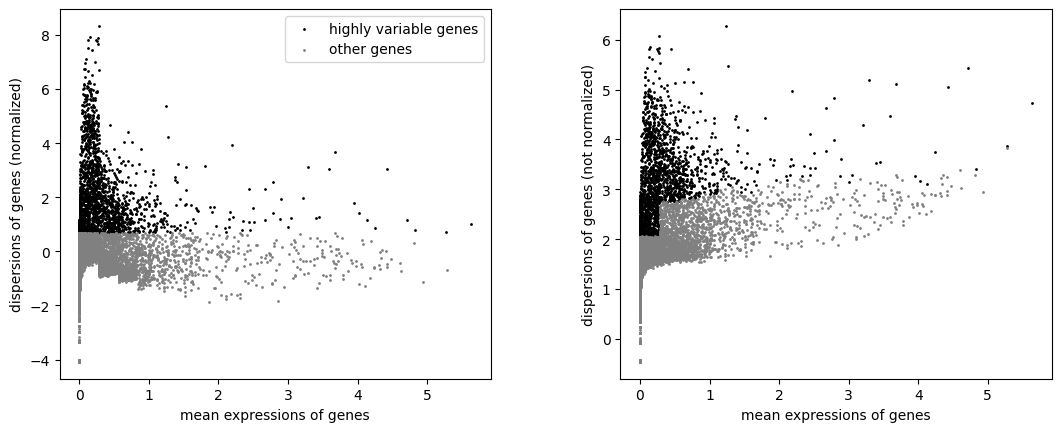

In [36]:
sc.pl.highly_variable_genes(adata)

In [40]:
adata = adata[
    :,
    adata.var.highly_variable
].copy()
print(adata)

AnnData object with n_obs × n_vars = 2694 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: None (.X)


In [41]:
sc.pp.scale(
    adata,
    max_value=10
)

In [42]:
sc.tl.pca(
    adata,
    n_comps=30
)

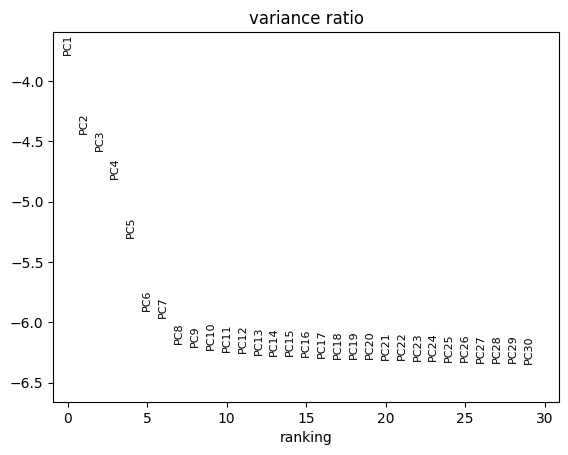

In [43]:
sc.pl.pca_variance_ratio(
    adata,
    log=True
)

In [44]:
print(adata.uns["pca"]["variance_ratio"][:30])

[0.02276173 0.01184085 0.0102712  0.00811847 0.00501425 0.00273156
 0.00257463 0.00208346 0.00203115 0.00197888 0.00194914 0.00192249
 0.00190021 0.00188109 0.00187661 0.00186497 0.001853   0.00183756
 0.00183499 0.00183004 0.00182129 0.00181019 0.00180245 0.00179699
 0.00179439 0.00178133 0.00177486 0.00177379 0.00176756 0.00176249]


In [45]:
sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=20
)

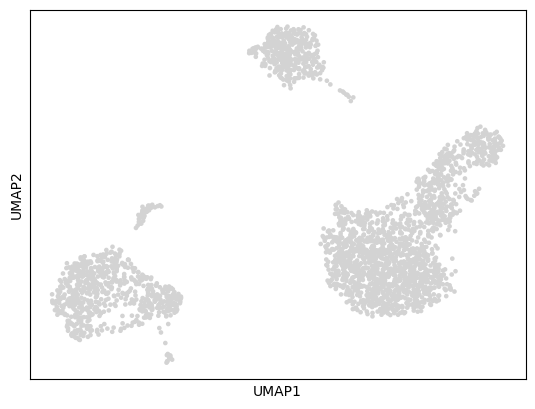

In [46]:
sc.tl.umap(adata)
sc.pl.umap(adata)

In [16]:
!pip install -q leidenalg

In [47]:
sc.tl.leiden(
    adata,
    resolution=0.5
)

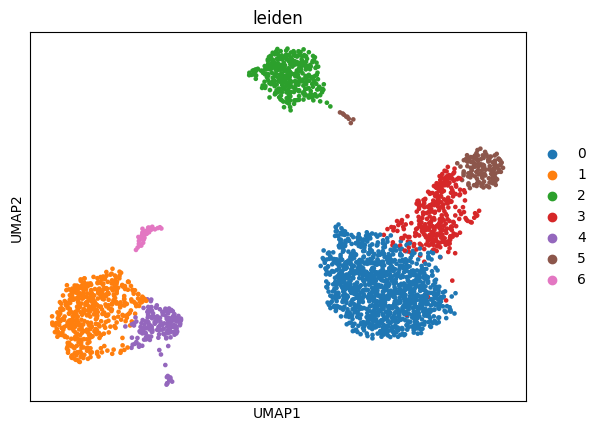

In [48]:
sc.pl.umap(
    adata,
    color="leiden"
)

In [49]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)

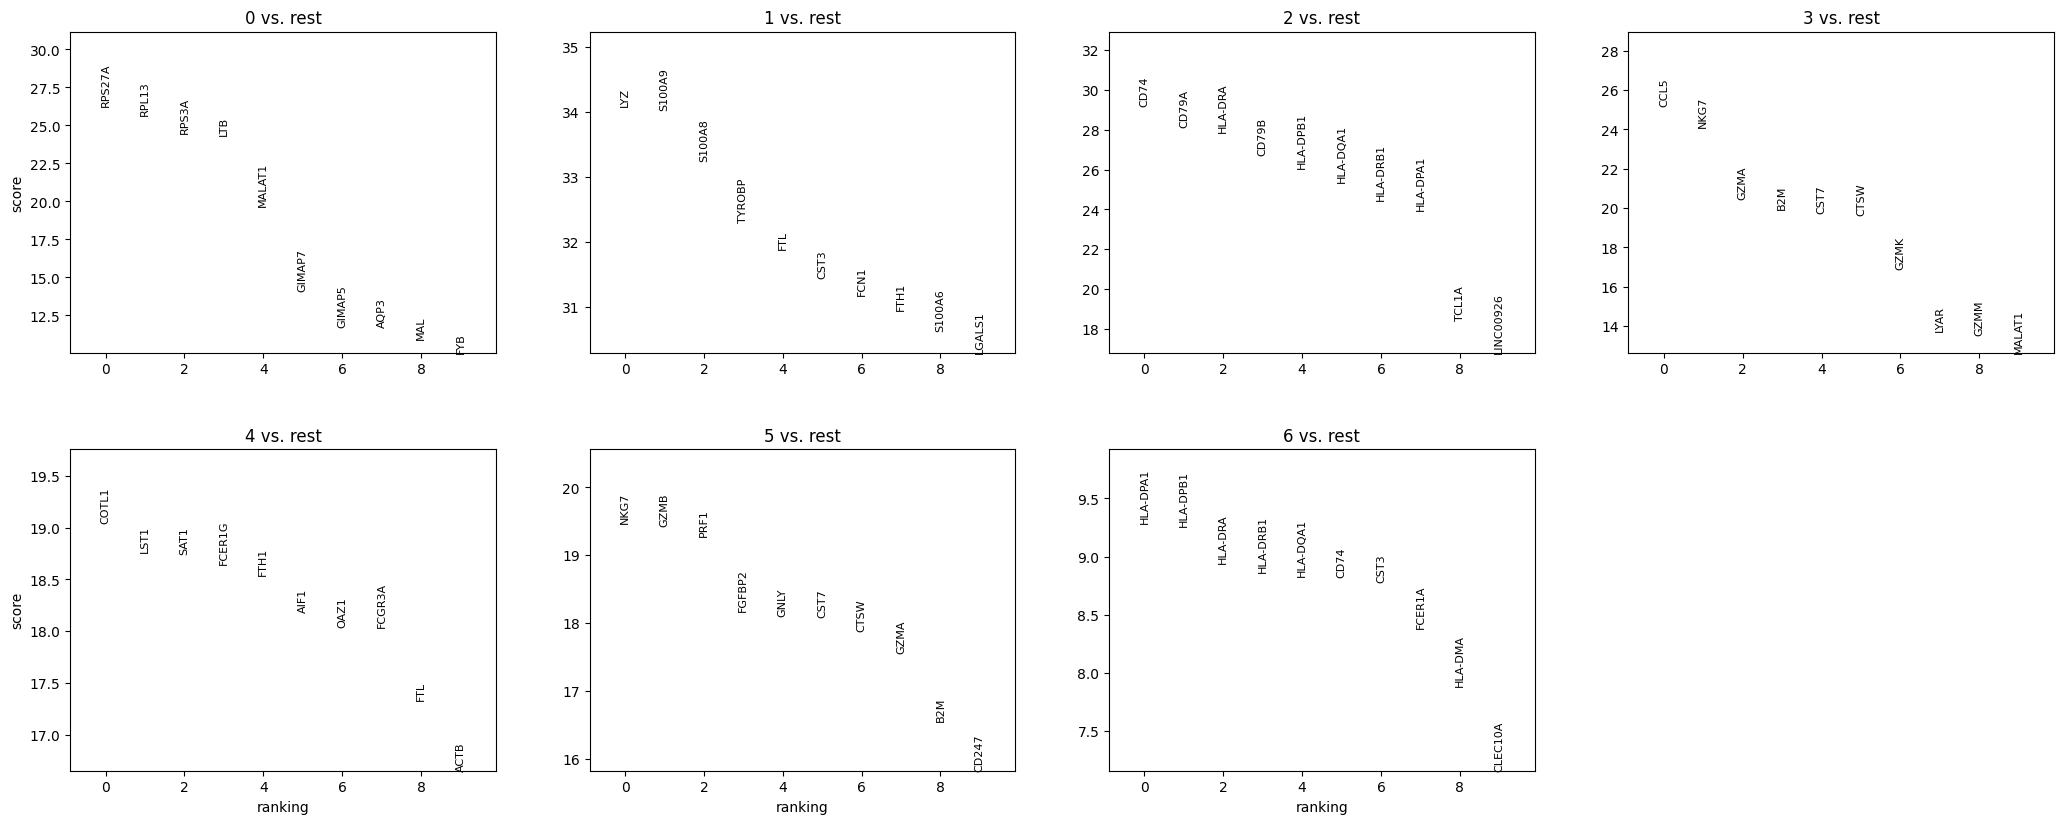

In [50]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

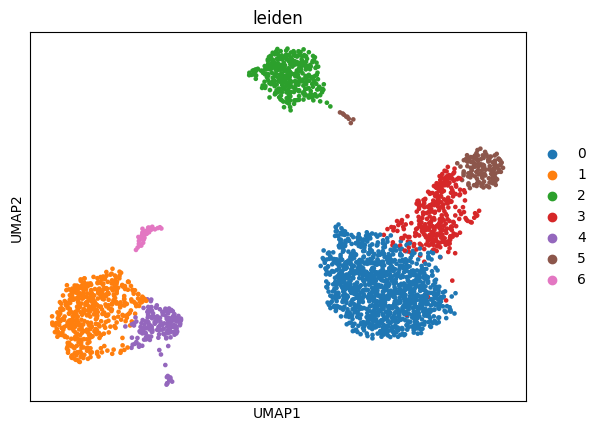

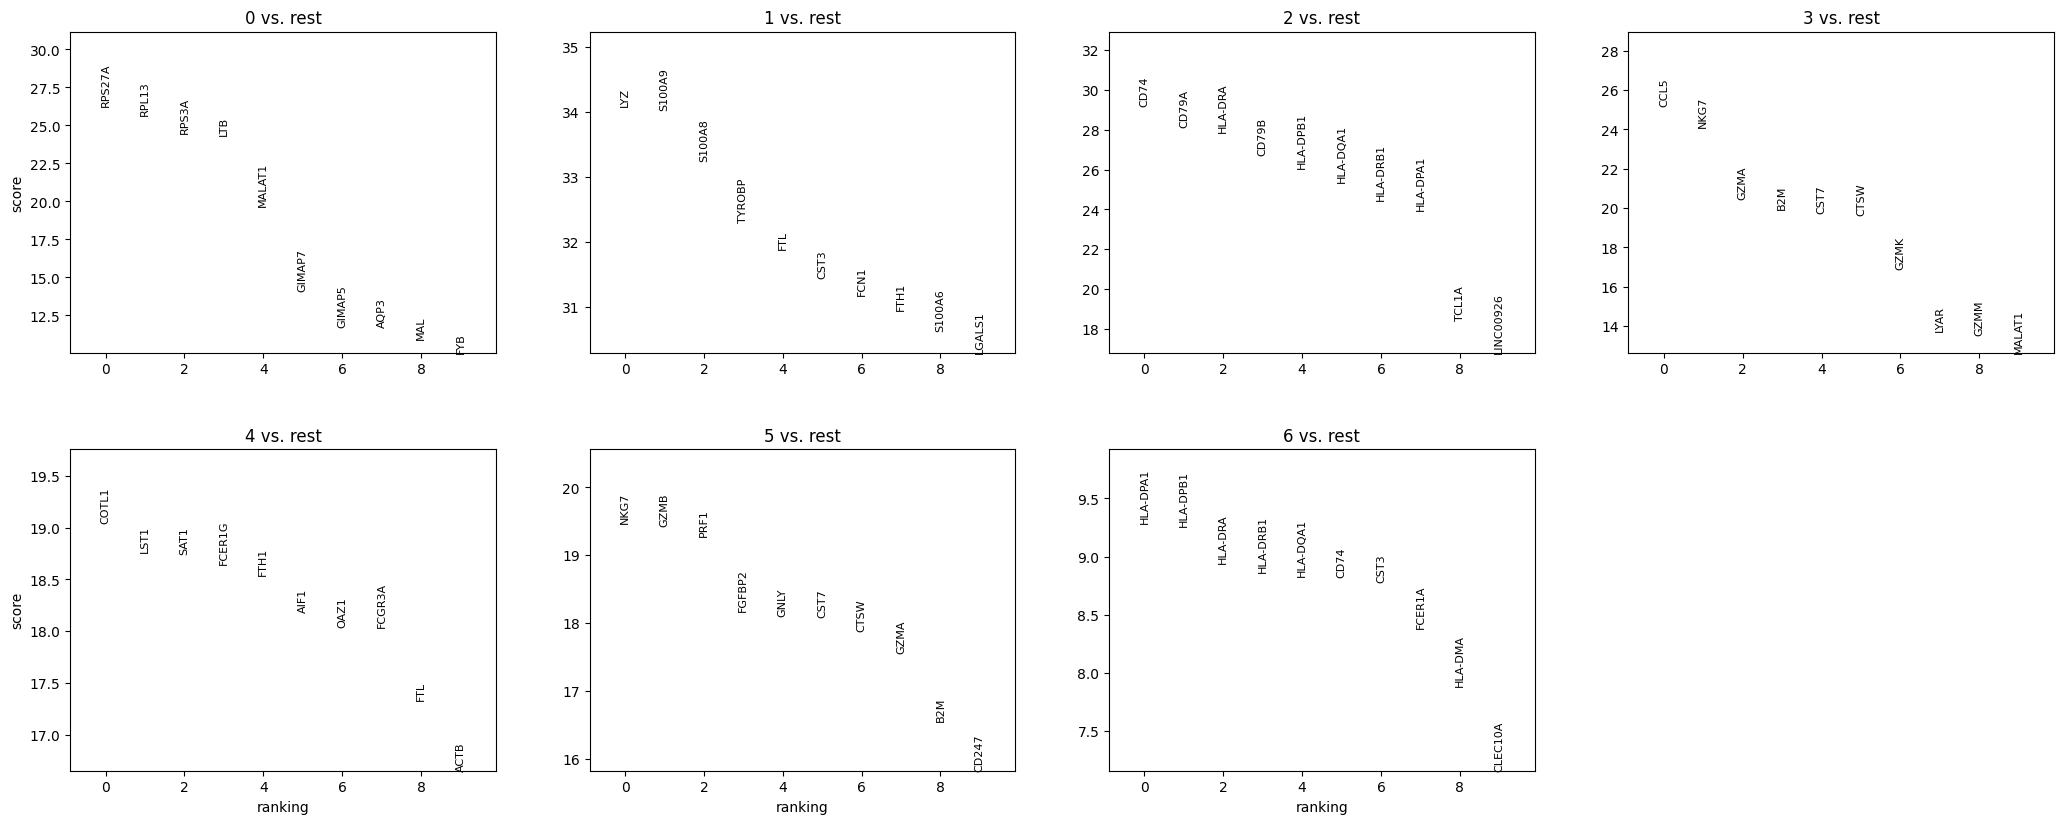

AnnData object with n_obs × n_vars = 2694 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X)
leiden
0    1168
1     494
2     349
3     330
4     170
5     148
6      35
Name: count, dtype: int64


In [51]:
adata
adata.obs["leiden"].value_counts()
sc.pl.umap(
    adata,
    color="leiden"
)
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)
print(adata)
print(adata.obs["leiden"].value_counts())

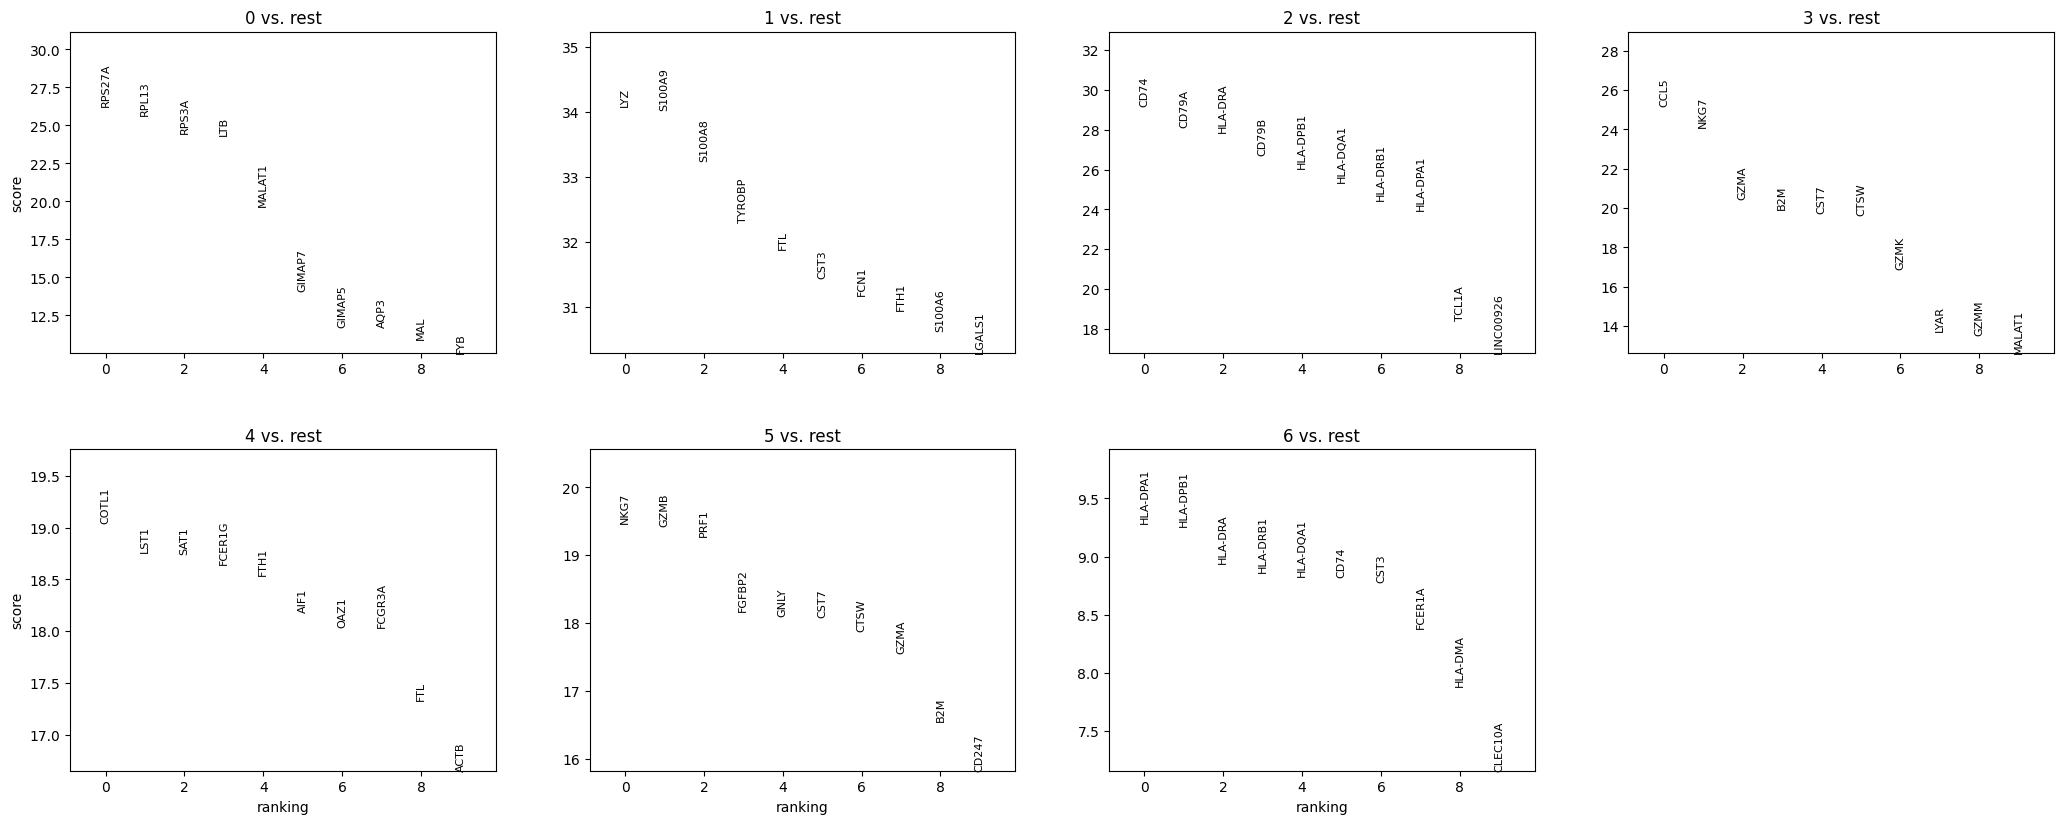

In [52]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon"
)
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [53]:
print(adata)
print(adata.obs["leiden"].value_counts())

AnnData object with n_obs × n_vars = 2694 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X)
leiden
0    1168
1     494
2     349
3     330
4     170
5     148
6      35
Name: count, dtype: int64


In [54]:
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,RPS27A,26.284719,NaN,2.867654e-152,9.558847e-150
1,0,RPL13,25.657797,NaN,3.460585e-145,9.887387e-143
2,0,RPS3A,24.460279,NaN,3.912085e-132,7.824169e-130
3,0,LTB,24.371937,NaN,3.394250e-131,6.171364e-129
4,0,MALAT1,19.664545,NaN,4.340497e-86,4.133807e-84
5,0,GIMAP7,14.064750,NaN,6.254360e-45,3.207364e-43
6,0,GIMAP5,11.701707,NaN,1.249155e-31,5.677976e-30
7,0,AQP3,11.698658,NaN,1.294852e-31,5.754899e-30
8,0,MAL,10.952804,NaN,6.442242e-28,2.629487e-26
9,0,FYB,10.025365,NaN,1.179235e-23,4.449944e-22


In [55]:
markers.groupby("group").head(10)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,RPS27A,26.284719,NaN,2.867654e-152,9.558847e-150
1,0,RPL13,25.657797,NaN,3.460585e-145,9.887387e-143
2,0,RPS3A,24.460279,NaN,3.912085e-132,7.824169e-130
3,0,LTB,24.371937,NaN,3.394250e-131,6.171364e-129
4,0,MALAT1,19.664545,NaN,4.340497e-86,4.133807e-84
...,...,...,...,...,...,...
12005,6,CD74,8.821687,NaN,1.127479e-18,3.758262e-16
12006,6,CST3,8.778159,NaN,1.661723e-18,4.747781e-16
12007,6,FCER1A,8.383343,NaN,5.144551e-17,1.286138e-14
12008,6,HLA-DMA,7.886377,NaN,3.110863e-15,6.913029e-13


In [56]:
for cluster in adata.obs["leiden"].cat.categories:
    print("\nCLUSTER:", cluster)
    print(
        markers[markers["group"] == cluster][
            ["names", "scores", "logfoldchanges", "pvals_adj"]
        ].head(10)
    )


CLUSTER: 0
    names     scores  logfoldchanges      pvals_adj
0  RPS27A  26.284719             NaN  9.558847e-150
1   RPL13  25.657797             NaN  9.887387e-143
2   RPS3A  24.460279             NaN  7.824169e-130
3     LTB  24.371937             NaN  6.171364e-129
4  MALAT1  19.664545             NaN   4.133807e-84
5  GIMAP7  14.064750             NaN   3.207364e-43
6  GIMAP5  11.701707             NaN   5.677976e-30
7    AQP3  11.698658             NaN   5.754899e-30
8     MAL  10.952804             NaN   2.629487e-26
9     FYB  10.025365             NaN   4.449944e-22

CLUSTER: 1
       names     scores  logfoldchanges      pvals_adj
2000     LYZ  34.091438             NaN  1.975776e-251
2001  S100A9  34.026600             NaN  9.008026e-251
2002  S100A8  33.242752             NaN  1.732034e-239
2003  TYROBP  32.301510             NaN  3.330742e-226
2004     FTL  31.893425             NaN  1.317488e-220
2005    CST3  31.443735             NaN  1.704249e-214
2006    FCN1  31.18

In [58]:
cell_type_map = {
    "0": "T cells",
    "1": "Classical monocytes",
    "2": "B cells",
    "3": "GZMK+ cytotoxic T cells",
    "4": "FCGR3A+ monocytes",
    "5": "NK cells",
    "6": "Dendritic cells"
}
adata.obs["cell_type"] = adata.obs["leiden"].map(cell_type_map)
adata.obs[["leiden", "cell_type"]].head()

,leiden,cell_type
index,,
AAACATACAACCAC-1,0,T cells
AAACATTGAGCTAC-1,2,B cells
AAACATTGATCAGC-1,0,T cells
AAACCGTGCTTCCG-1,1,Classical monocytes
AAACCGTGTATGCG-1,5,NK cells


In [59]:
adata.obs["cell_type"].value_counts()

cell_type
T cells                    1168
Classical monocytes         494
B cells                     349
GZMK+ cytotoxic T cells     330
FCGR3A+ monocytes           170
NK cells                    148
Dendritic cells              35
Name: count, dtype: int64

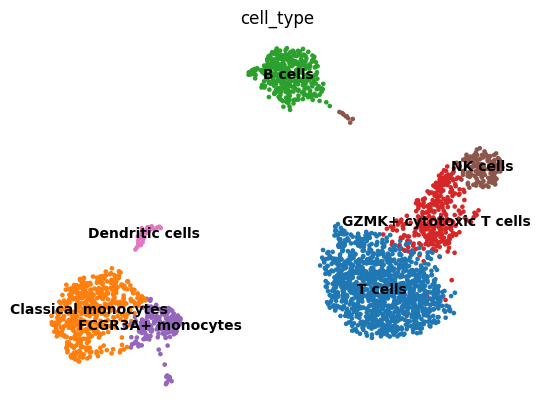

In [60]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    frameon=False
)

In [72]:
print(adata)
print(adata.X.shape)
print(adata.var_names[:10])

AnnData object with n_obs × n_vars = 2694 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X)
(2694, 2000)
Index(['TNFRSF4', 'CPSF3L', 'ATAD3C', 'RER1', 'TNFRSF25', 'TNFRSF9',
       'CTNNBIP1', 'UBIAD1', 'DRAXIN', 'NPPA-AS1'],
      dtype='str', name='index')


In [90]:
adata.obs["cell_type"].value_counts()

cell_type
T cells                    1168
Classical monocytes         494
B cells                     349
GZMK+ cytotoxic T cells     330
FCGR3A+ monocytes           170
NK cells                    148
Dendritic cells              35
Name: count, dtype: int64

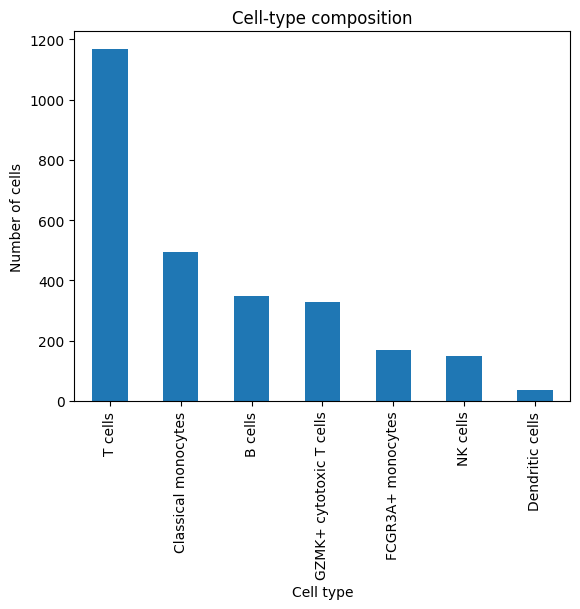

In [92]:
adata.obs["cell_type"].value_counts().plot.bar()

import matplotlib.pyplot as plt
plt.ylabel("Number of cells")
plt.xlabel("Cell type")
plt.title("Cell-type composition")
plt.xticks(rotation=90)
plt.show()

In [93]:
markers = [
    "CD3D",
    "CD3E",
    "MS4A1",
    "CD79A",
    "NKG7",
    "GNLY",
    "LYZ",
    "S100A8",
    "S100A9",
    "FCGR3A",
    "FCER1A"
]

available_markers = [
    gene for gene in markers
    if gene in adata.var_names
]

print(available_markers)

['CD79A', 'NKG7', 'GNLY', 'LYZ', 'S100A8', 'S100A9', 'FCGR3A', 'FCER1A']


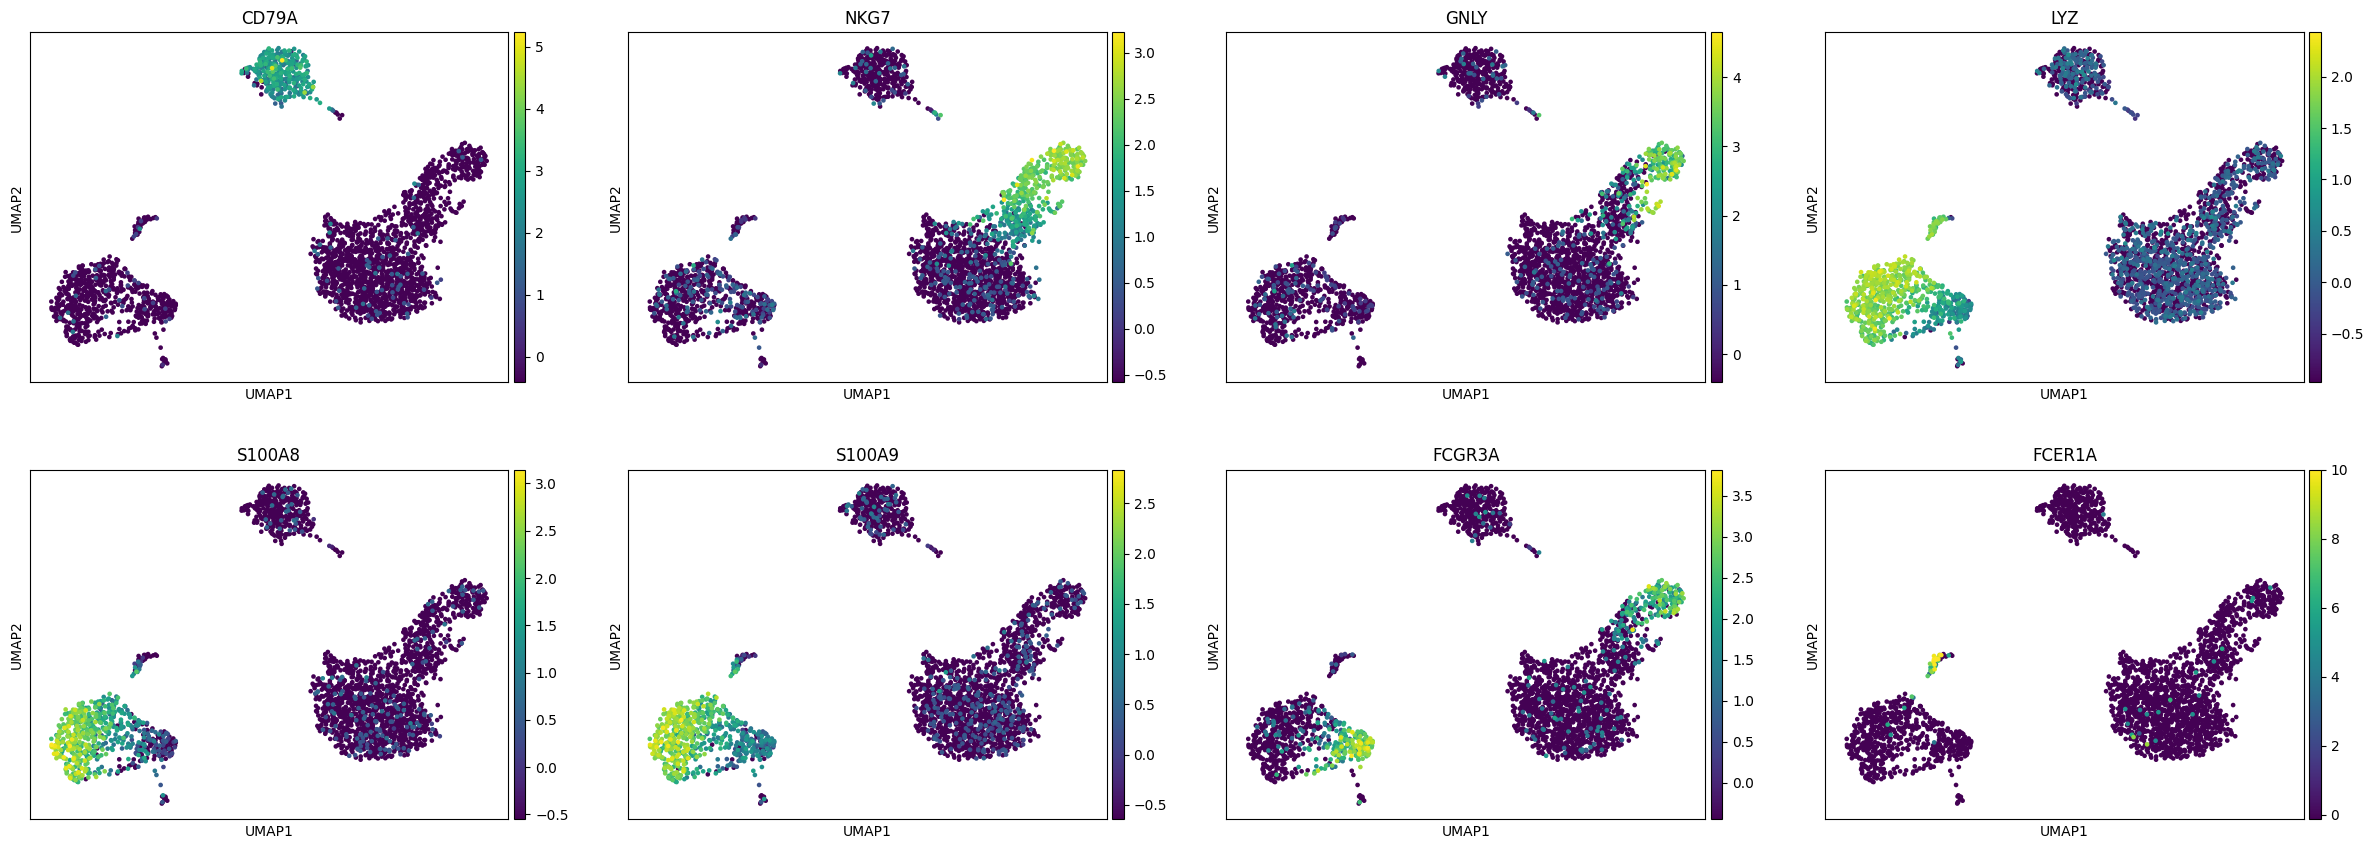

In [95]:
sc.pl.umap(
    adata,
    color=available_markers
)

In [96]:
sc.tl.rank_genes_groups(
    adata,
    groupby="cell_type",
    method="wilcoxon"
)

/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.13/dist-packages/scanpy/tools/_rank_genes_groups.py:633: 

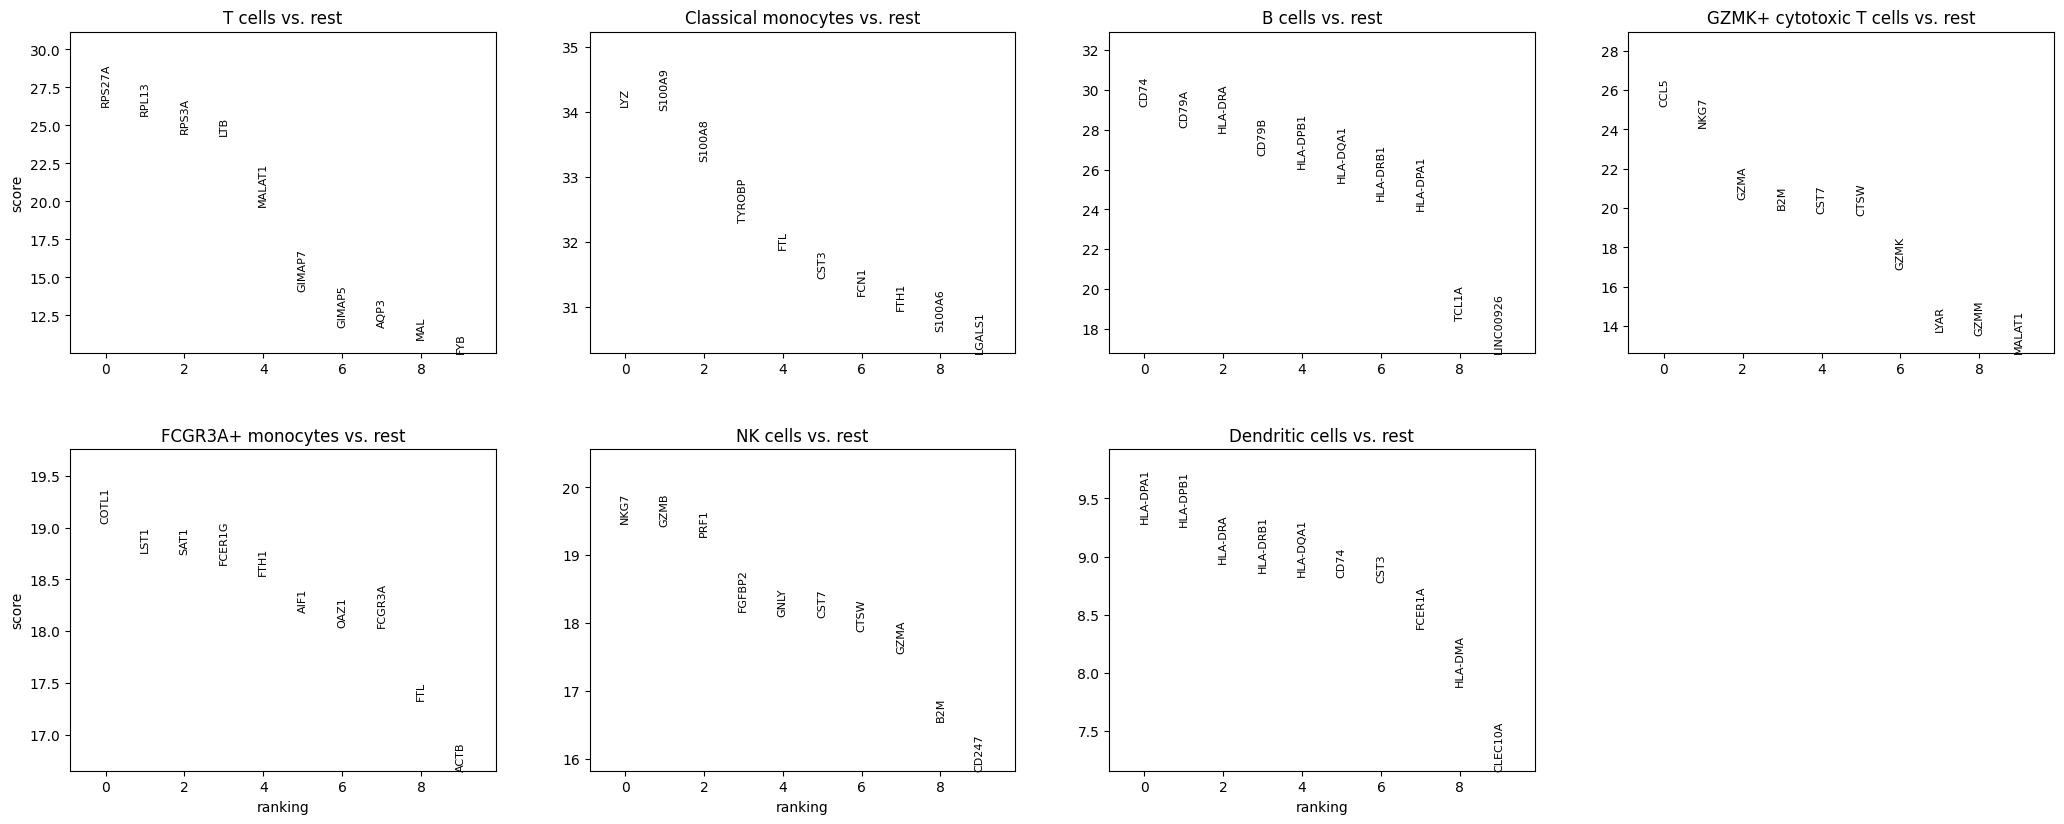

In [97]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [98]:
de_results = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

de_results.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,T cells,RPS27A,26.284719,NaN,2.867654e-152,9.558847e-150
1,T cells,RPL13,25.657797,NaN,3.460585e-145,9.887387e-143
2,T cells,RPS3A,24.460279,NaN,3.912085e-132,7.824169e-130
3,T cells,LTB,24.371937,NaN,3.394250e-131,6.171364e-129
4,T cells,MALAT1,19.664545,NaN,4.340497e-86,4.133807e-84


In [99]:
de_results.to_csv(
    "cell_type_marker_genes.csv",
    index=False
)

In [100]:
for cell_type in adata.obs["cell_type"].unique():

    print("\nCELL TYPE:", cell_type)

    result = de_results[
        de_results["group"] == cell_type
    ]

    print(
        result[
            ["names", "scores", "pvals_adj"]
        ].head(10)
    )


CELL TYPE: T cells
    names     scores      pvals_adj
0  RPS27A  26.284719  9.558847e-150
1   RPL13  25.657797  9.887387e-143
2   RPS3A  24.460279  7.824169e-130
3     LTB  24.371937  6.171364e-129
4  MALAT1  19.664545   4.133807e-84
5  GIMAP7  14.064750   3.207364e-43
6  GIMAP5  11.701707   5.677976e-30
7    AQP3  11.698658   5.754899e-30
8     MAL  10.952804   2.629487e-26
9     FYB  10.025365   4.449944e-22

CELL TYPE: B cells
          names     scores      pvals_adj
4000       CD74  29.203844  3.466111e-184
4001      CD79A  28.102961  9.013073e-171
4002    HLA-DRA  27.881456  2.985440e-168
4003      CD79B  26.733217  9.676806e-155
4004   HLA-DPB1  26.085043  2.155725e-147
4005   HLA-DQA1  25.363216  2.141357e-139
4006   HLA-DRB1  24.437515  1.951891e-129
4007   HLA-DPA1  23.967953  1.501377e-124
4008      TCL1A  18.439894   1.142985e-73
4009  LINC00926  16.791777   4.672056e-61

CELL TYPE: Classical monocytes
       names     scores      pvals_adj
2000     LYZ  34.091438  1.9757

In [101]:
adata.write_h5ad(
    "PBMC3k_annotated.h5ad"
)

In [1]:
!pip install -q celltypist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 704.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.6 MB

In [2]:
import celltypist
print(celltypist.__version__)

/usr/local/lib/python3.13/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


1.7.1


In [3]:
celltypist.models.download_models()


In [4]:
celltypist.models.models_description()

,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
...,...,...
56,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...
57,PaediatricAdult_COVID19_Airway.pkl,cell types in the airway of paediatric and adu...
58,PaediatricAdult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types of pae...
59,Pan_Fetal_Human.pkl,stromal and immune populations from the human ...


In [7]:
adata_full = sc.datasets.pbmc3k()

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

In [8]:
adata_full.var["mt"] = adata_full.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata_full,
    qc_vars=["mt"],
    inplace=True
)

adata_full = adata_full[
    (adata_full.obs.n_genes_by_counts > 200) &
    (adata_full.obs.pct_counts_mt < 10),
    :
].copy()

In [9]:
sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

In [10]:
import celltypist
from celltypist import models

In [11]:
predictions = celltypist.annotate(
    adata_full,
    model="Immune_All_Low.pkl",
    majority_voting=True
)

In [12]:
predictions.predicted_labels.head()

,predicted_labels,over_clustering,majority_voting
index,,,
AAACATACAACCAC-1,Trm cytotoxic T cells,0,Tcm/Naive helper T cells
AAACATTGAGCTAC-1,B cells,3,B cells
AAACATTGATCAGC-1,Tcm/Naive helper T cells,5,Tcm/Naive helper T cells
AAACCGTGCTTCCG-1,Classical monocytes,6,Non-classical monocytes
AAACCGTGTATGCG-1,CD16+ NK cells,9,CD16+ NK cells


In [13]:
adata_full.obs["celltypist_label"] = predictions.predicted_labels["majority_voting"]

In [18]:
sc.tl.umap(adata_full)

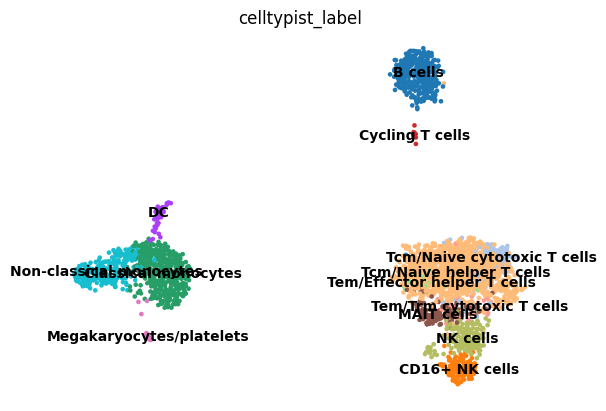

In [19]:
sc.pl.umap(
    adata_full,
    color="celltypist_label",
    legend_loc="on data",
    frameon=False
)

In [61]:
sc.tl.umap(adata)

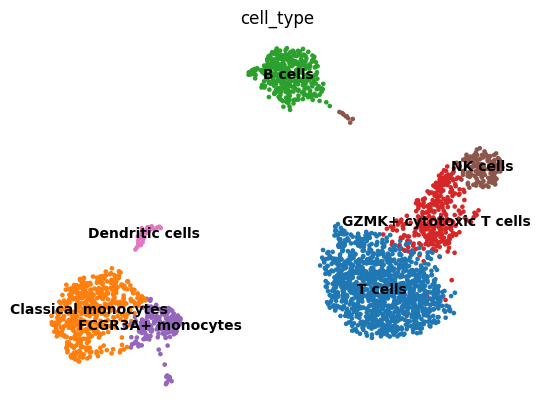

In [62]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data",
    frameon=False
)

In [63]:
comparison = pd.crosstab(
    adata.obs["cell_type"],
    adata_full.obs["celltypist_label"]
)

comparison


celltypist_label,B cells,CD16+ NK cells,Classical monocytes,Cycling T cells,DC,MAIT cells,Megakaryocytes/platelets,NK cells,Non-classical monocytes,Tcm/Naive cytotoxic T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Trm cytotoxic T cells
cell_type,,,,,,,,,,,,,
T cells,0,0,0,1,0,21,0,0,0,94,1012,29,11
Classical monocytes,0,0,412,0,5,0,0,0,77,0,0,0,0
B cells,345,0,0,0,0,0,0,0,0,0,4,0,0
GZMK+ cytotoxic T cells,1,4,0,0,0,97,0,151,0,10,48,3,16
FCGR3A+ monocytes,0,0,2,0,0,0,15,0,153,0,0,0,0
NK cells,0,126,0,8,0,0,0,14,0,0,0,0,0
Dendritic cells,0,0,0,0,35,0,0,0,0,0,0,0,0


In [64]:
common_cells = adata.obs_names.intersection(adata_full.obs_names)

comparison = pd.crosstab(
    adata.obs.loc[common_cells, "cell_type"],
    adata_full.obs.loc[common_cells, "celltypist_label"]
)

comparison

celltypist_label,B cells,CD16+ NK cells,Classical monocytes,Cycling T cells,DC,MAIT cells,Megakaryocytes/platelets,NK cells,Non-classical monocytes,Tcm/Naive cytotoxic T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Trm cytotoxic T cells
cell_type,,,,,,,,,,,,,
T cells,0,0,0,1,0,21,0,0,0,94,1012,29,11
Classical monocytes,0,0,412,0,5,0,0,0,77,0,0,0,0
B cells,345,0,0,0,0,0,0,0,0,0,4,0,0
GZMK+ cytotoxic T cells,1,4,0,0,0,97,0,151,0,10,48,3,16
FCGR3A+ monocytes,0,0,2,0,0,0,15,0,153,0,0,0,0
NK cells,0,126,0,8,0,0,0,14,0,0,0,0,0
Dendritic cells,0,0,0,0,35,0,0,0,0,0,0,0,0


In [66]:
comparison = pd.crosstab(
    adata.obs["cell_type"],
    adata_full.obs["celltypist_label"]
)
comparison.to_csv("celltypist_vs_manual_annotation.csv")